<a href="https://colab.research.google.com/github/akash-g0807/Numerical-Analysis/blob/main/7_ODE_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def euler_1d(f, x0, t0, tmax, dt):
    # We need an integer number of steps so we round the number of steps
    # and then adjust dt to match.
    N = round((tmax - t0) / dt)
    dt = (tmax - t0) / N

    # Set up the time grid
    t = np.linspace(t0, tmax, N + 1)

    # Set up an array for x that is the same size as t
    x = np.zeros(len(t))

    # Fill in the initial condition
    x[0] = x0

    # Euler steps
    for n in range(N):
        x[n + 1] = x[n] + dt * f(t[n], x[n])

    return t, x

In [ ]:
f = lambda t, x: np.sin(x**2) + t
dt = 0.1
t0 = 1
x0 = 0.7
tmax = 2.5
t, x = euler_1d(f, x0, t0, tmax, dt)
print(x[-1])
print(t,x)

3.311946160751847
[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5] [0.7        0.84706259 1.02281403 1.22936407 1.45918735 1.68399608
 1.86409691 1.99138393 2.08799587 2.17415022 2.26416079 2.3726103
 2.52178119 2.74939333 3.07507884 3.31194616]


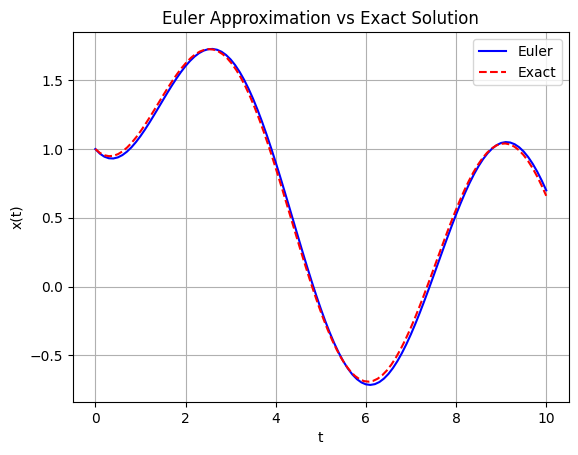

In [ ]:
# Define the differential equation x' = -(1/3)x + sin(t)
f = lambda t, x: -(1/3)*x + np.sin(t)

x0 = 1      # initial condition
t0 = 0      # initial time
tmax = 10   # final time
dt = 0.1    # time step

# Compute Euler approximation
t, x = euler_1d(f, x0, t0, tmax, dt)
plt.plot(t, x, 'b-', label='Euler')

# Exact solution
x_exact = lambda t: (1/10) * (19*np.exp(-t/3) + 3*np.sin(t) - 9*np.cos(t))

# Plot exact solution on a finer grid
t_hires = np.linspace(t0, tmax, 100)
plt.plot(t_hires, x_exact(t_hires), 'r--', label='Exact')

plt.xlabel('t')
plt.ylabel('x(t)')
plt.title("Euler Approximation vs Exact Solution")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Define the differential equation x' = -x + sin(t/2)
f = lambda t, x: -x + np.sin(t/2)

# Initial condition and parameters
x0 = 1
t0 = 0
tmax = 10
dt = 1

# Run Euler method
t, x = euler_1d(f, x0, t0, tmax, dt)

# Print result
print("t values:", t)
print("x values:", x)
print("Approximation of x(10):", x[-1])

t values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
x values: [ 1.          0.          0.47942554  0.84147098  0.99749499  0.90929743
  0.59847214  0.14112001 -0.35078323 -0.7568025  -0.97753012]
Approximation of x(10): -0.977530117665097


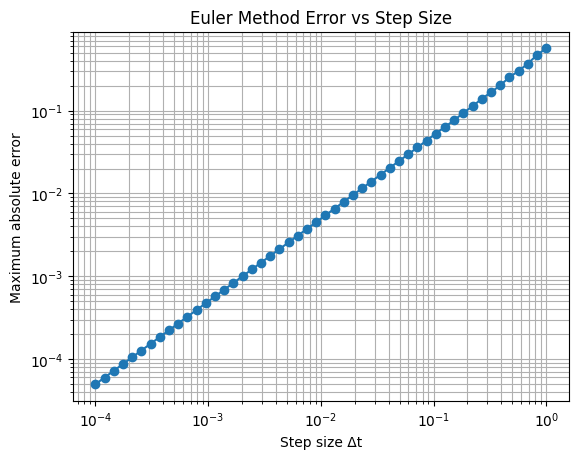

1.008609370346568


In [ ]:
f = lambda t, x: -(1/3)*x + np.sin(t)
x_exact = lambda t: (1/10) * (19*np.exp(-t/3) + 3*np.sin(t) - 9*np.cos(t))

# Create vector with different step sizes
dt = 10**(-np.linspace(0, 4, 50))

# Create vector for holding the errors
errors = np.zeros_like(dt)

# Loop over step sizes
for i in range(len(dt)):
    t, x = euler_1d(f, x0, t0, tmax, dt[i])

    # Maximum absolute error over all grid points
    errors[i] = np.max(np.abs(x - x_exact(t)))

# Plot error vs step size on log-log axes
plt.loglog(dt, errors, 'o-')
plt.xlabel('Step size Δt')
plt.ylabel('Maximum absolute error')
plt.title("Euler Method Error vs Step Size")
plt.grid(True, which='both')
plt.show()
m, b = np.polyfit(np.log(dt), np.log(errors), 1)
print(m)

In [ ]:
def euler(F, x0, t0, tmax, dt):
    # We need an integer number of steps so we round the number of steps
    # and then adjust dt to match.
    N = round((tmax - t0) / dt)
    dt = (tmax - t0) / N

    # Set up the time grid
    t = np.linspace(t0, tmax, N + 1)

    # Set up an array for x with one row for each time step
    # and one column for each dependent variable
    x = np.zeros((len(t), len(x0)))

    # Store the initial condition in the first row of x
    x[0, :] = x0

    # Loop over the different time steps
    for n in range(N):
        x[n + 1, :] = x[n, :] + dt * F(t[n], x[n, :])

    return t, x

In [ ]:
m = 2
b = 40
k = 128

F = lambda t, x: np.array([x[1], -20*x[1] - 64*x[0]])

# initial position x = 0, initial velocity = 0.6
x0 = [0, 0.6]

t0 = 0
tmax = 5
dt = 0.01

t, x = euler(F, x0, t0, tmax, dt)

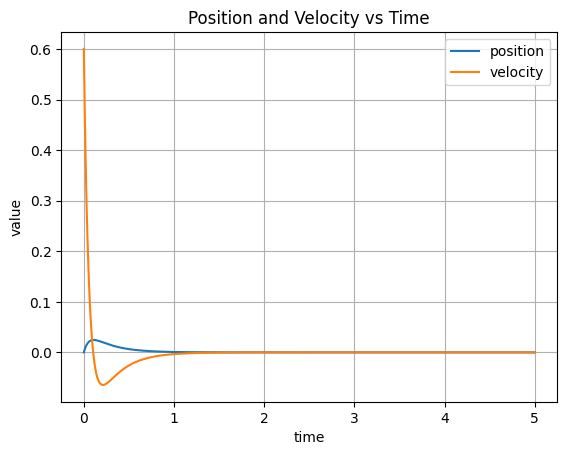

In [ ]:
position = x[:, 0]
velocity = x[:, 1]

plt.plot(t, position, label='position')
plt.plot(t, velocity, label='velocity')
plt.grid()
plt.legend()
plt.xlabel('time')
plt.ylabel('value')
plt.title('Position and Velocity vs Time')
plt.show()

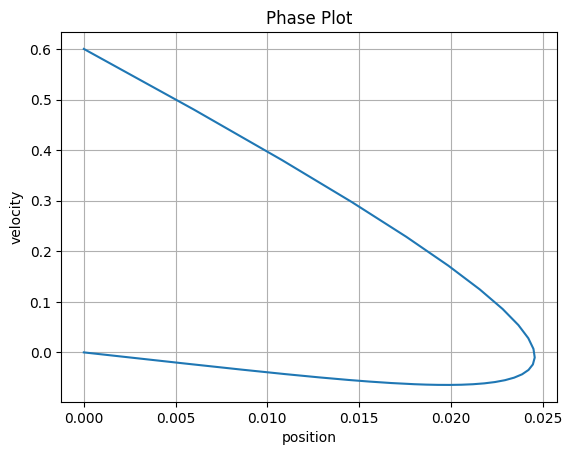

In [ ]:
plt.plot(x[:,0], x[:,1])
plt.grid()
plt.title('Phase Plot')
plt.xlabel('position')
plt.ylabel('velocity')
plt.show()

[ 0.4000368  -0.42115001]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5
 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ] [[ 2.          0.        ]
 [ 2.         -0.4       ]
 [ 1.96       -0.768     ]
 [ 1.8832     -1.09856   ]
 [ 1.773344   -1.3873152 ]
 [ 1.63461248 -1.63099878]
 [ 1.4715126  -1.82744138]
 [ 1.28876846 -1.97554859]
 [ 1.09121361 -2.07525839]
 [ 0.88368777 -2.12748044]
 [ 0.67093972 -2.13401956]
 [ 0.45753777 -2.09748594]
 [ 0.24778917 -2.02119462]
 [ 0.04566971 -1.90905688]
 [-0.14523598 -1.76546627]
 [-0.32178261 -1.59518178]
 [-0.48130078 -1.40321071]
 [-0.62162185 -1.1946937 ]
 [-0.74109122 -0.97479383]
 [-0.83857061 -0.74859208]
 [-0.91342982 -0.52099059]
 [-0.96552888 -0.29662538]
 [-0.99519141 -0.07978958]
 [-1.00317037  0.12563187]
 [-0.99060718  0.3162154 ]
 [-0.95898564  0.4890396 ]
 [-0.91008168  0.64171356]
 [-0.84591033  0.77239281]
 [-0.76867

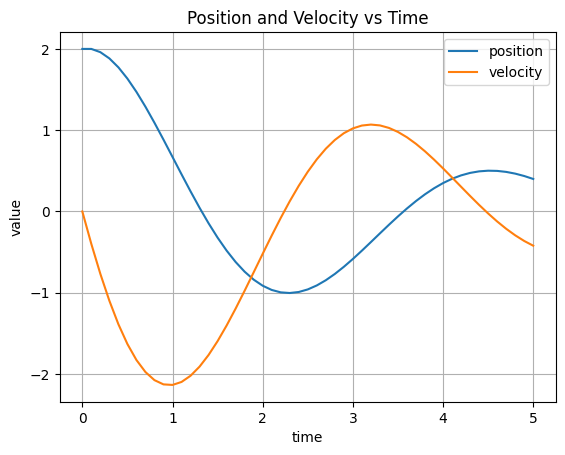

Number of local maxima in velocity: 1


In [ ]:
m = 5
b = 4
k = 10

F = lambda t, x: np.array([x[1], -(b/m)*x[1] - (k/m)*x[0]])

x0 = [2, 0]
t0 = 0
tmax = 5
dt = 0.1

t, x = euler(F, x0, t0, tmax, dt)
print(x[-1])
print(t,x)

position = x[:, 0]
velocity = x[:, 1]

plt.plot(t, position, label='position')
plt.plot(t, velocity, label='velocity')
plt.grid()
plt.legend()
plt.xlabel('time')
plt.ylabel('value')
plt.title('Position and Velocity vs Time')
plt.show()

# Count local maxima of velocity
count = 0
for i in range(1, len(velocity)-1):
    if velocity[i-1] < velocity[i] and velocity[i] > velocity[i+1]:
        count += 1

print("Number of local maxima in velocity:", count)

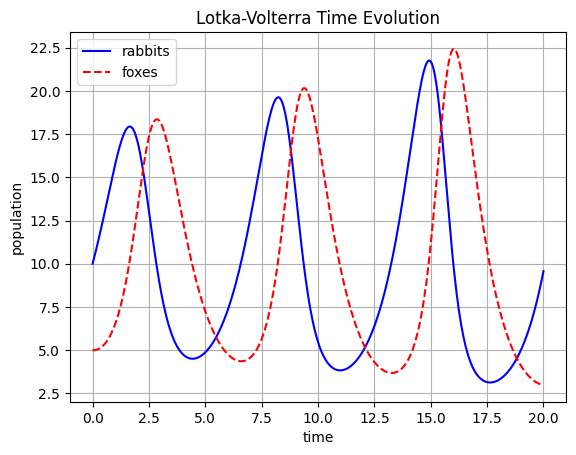

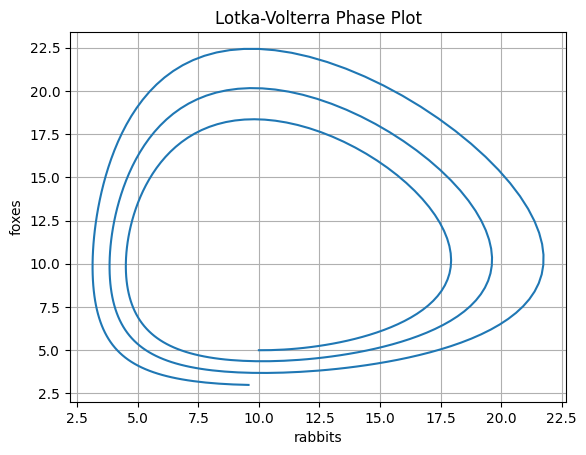

In [ ]:
# Parameters
alpha = 1
beta = 0.1
gamma = 1
delta = 0.1

# Lotka-Volterra system
F = lambda t, x: np.array([
    alpha * x[0] - beta * x[0] * x[1],
    delta * x[0] * x[1] - gamma * x[1]
])

# Initial conditions and solver settings
x0 = [10, 5]   # rabbits, foxes
t0 = 0
tmax = 20
dt = 0.05

t, x = euler(F, x0, t0, tmax, dt)

# Time evolution plot
plt.plot(t, x[:, 0], 'b-', label='rabbits')
plt.plot(t, x[:, 1], 'r--', label='foxes')
plt.grid()
plt.legend()
plt.xlabel('time')
plt.ylabel('population')
plt.title('Lotka-Volterra Time Evolution')
plt.show()

# Phase plot
plt.plot(x[:, 0], x[:, 1])
plt.grid()
plt.xlabel('rabbits')
plt.ylabel('foxes')
plt.title('Lotka-Volterra Phase Plot')
plt.show()

In [ ]:
def midpoint_1d(f, x0, t0, tmax, dt):
    N = round((tmax - t0) / dt)
    dt = (tmax - t0) / N

    # build the times
    t = np.linspace(t0, tmax, N + 1)

    # build an array for x values
    x = np.zeros(len(t))

    # save the initial condition
    x[0] = x0

    # loop over time steps
    for n in range(N):
        # slope at current point
        slope = f(t[n], x[n])

        # half-step estimate
        x_halfstep = x[n] + (dt / 2) * slope

        # slope at midpoint and full step update
        x[n + 1] = x[n] + dt * f(t[n] + dt / 2, x_halfstep)

    return t, x

In [ ]:
f = lambda t, x: 8*t - 2*x
dt = 1/2
t0 = 0
x0 = 4
tmax = 2.5
t, x = midpoint_1d(f, x0, t0, tmax, dt)
print(x[-1])
print(t,x)

8.1875
[0.  0.5 1.  1.5 2.  2.5] [4.     3.     3.5    4.75   6.375  8.1875]


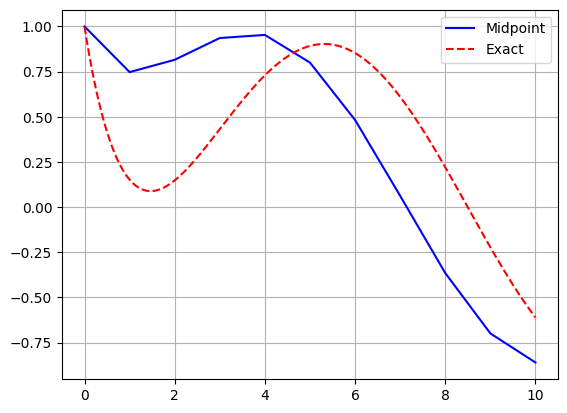

x(10) ≈ -0.8600551874653649


In [ ]:
# ODE: x' = -x + sin(t/2)
f = lambda t, x: -x + np.sin(t/2)

x0 = 1        # initial condition
t0 = 0
tmax = 10
dt = 1        # step size

# midpoint solver
t, x = midpoint_1d(f, x0, t0, tmax, dt)

# plot midpoint solution
plt.plot(t, x, 'b-', label='Midpoint')

# exact solution
x_exact = lambda t: (2/5)*(np.sin(t/2) - 2*np.cos(t/2)) + (1 + 4/5)*np.exp(-t)

# high resolution for smooth curve
t_fine = np.linspace(t0, tmax, 200)
plt.plot(t_fine, x_exact(t_fine), 'r--', label='Exact')

plt.legend()
plt.grid()
plt.show()

# print approximation at t = 10
print("x(10) ≈", x[-1])

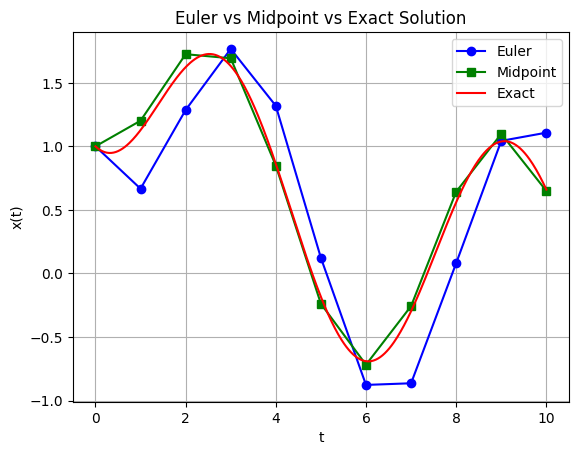

In [ ]:
# ODE and exact solution
f = lambda t, x: -(1/3) * x + np.sin(t)
x_exact = lambda t: (1/10) * (19 * np.exp(-t/3) + 3 * np.sin(t) - 9 * np.cos(t))

# Initial data
x0 = 1
t0 = 0
tmax = 10
dt = 1

# Numerical solutions
t_euler, x_euler = euler_1d(f, x0, t0, tmax, dt)
t_mid, x_mid = midpoint_1d(f, x0, t0, tmax, dt)


# Exact solution on a finer grid
t_fine = np.linspace(t0, tmax, 400)
x_fine = x_exact(t_fine)

# Plot all three
plt.plot(t_euler, x_euler, 'bo-', label='Euler')
plt.plot(t_mid, x_mid, 'gs-', label='Midpoint')
plt.plot(t_fine, x_fine, 'r-', label='Exact')

plt.xlabel('t')
plt.ylabel('x(t)')
plt.title("Euler vs Midpoint vs Exact Solution")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
f = lambda t, x: -(1/3)*x + np.sin(t)
x_exact = lambda t: (1/10) * (19*np.exp(-t/3) + 3*np.sin(t) - 9*np.cos(t))

# Create vector with different step sizes
dt = 2**(-np.linspace(0, 8, 80))

# Create vector for holding the errors
errors = np.zeros_like(dt)

# Loop over step sizes
for i in range(len(dt)):
    t, x = midpoint_1d(f, x0, t0, tmax, dt[i])

    # Maximum absolute error over all grid points
    #errors[i] = np.max(np.abs(x - x_exact(t)))
    errors[i] = (np.abs(x[-1] - x_exact(t)[-1]))


# Plot error vs step size on log-log axes
plt.loglog(dt, errors, 'o-')
plt.xlabel('Step size Δt')
plt.ylabel('Maximum absolute error')
plt.title("Euler Method Error vs Step Size")
plt.grid(True, which='both')
plt.show()
m, b = np.polyfit(np.log(dt), np.log(errors), 1)
print(m)

ValueError: setting an array element with a sequence.

In [ ]:
def midpoint(F, x0, t0, tmax, dt):
    N = round((tmax - t0) / dt)
    dt = (tmax - t0) / N
    t = np.linspace(t0, tmax, N + 1)

    x = np.zeros((len(t), len(x0)))
    x[0, :] = x0

    for n in range(N):
        x_half = x[n, :] + (dt / 2) * F(t[n], x[n, :])
        x[n + 1, :] = x[n, :] + dt * F(t[n] + dt / 2, x_half)

    return t, x

In [ ]:
m = 2
b = 4
k = 128

F = lambda t, x: np.array([x[1], -2*x[1] - 64*x[0]])

x0 = [-0.2, 0.6]
t0 = 0
tmax = 5
dt = 0.1

t, x = midpoint(F, x0, t0, tmax, dt)

print("x(5) ≈", x[-1, 0])
print("velocity at t=5 ≈", x[-1, 1])

x(5) ≈ -0.004350228275502041
velocity at t=5 ≈ 0.014538597100950748
